<a href="https://colab.research.google.com/github/paulAnirban12/Deep-Learning/blob/main/image_classification_mlp_optimizer_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
kentvejrupmadsen_letter_images_dataset_path = kagglehub.dataset_download('kentvejrupmadsen/letter-images-dataset')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/letter-images-dataset/License.md
/kaggle/input/letter-images-dataset/dataset/N/ids_0224.jpg
/kaggle/input/letter-images-dataset/dataset/N/ids_0288.jpg
/kaggle/input/letter-images-dataset/dataset/N/ids_0599.jpg
/kaggle/input/letter-images-dataset/dataset/N/ids_0731.jpg
/kaggle/input/letter-images-dataset/dataset/N/ids_1375.jpg
/kaggle/input/letter-images-dataset/dataset/N/ids_0438.jpg
/kaggle/input/letter-images-dataset/dataset/N/ids_0644.jpg
/kaggle/input/letter-images-dataset/dataset/N/ids_0003.jpg
/kaggle/input/letter-images-dataset/dataset/N/ids_0722.jpg
/kaggle/input/letter-images-dataset/dataset/N/ids_0874.jpg
/kaggle/input/letter-images-dataset/dataset/N/ids_0222.jpg
/kaggle/input/letter-images-dataset/dataset/N/ids_0743.jpg
/kaggle/input/letter-images-dataset/dataset/N/ids_0706.jpg
/kaggle/input/letter-images-dataset/dataset/N/ids_1223.jpg
/kaggle/input/letter-images-dataset/dataset/N/ids_0863.jpg
/kaggle/input/letter-images-dataset/dataset/N/ids_1144.jpg
/kaggle/i

In [ ]:
pip install tensorflow matplotlib

Note: you may need to restart the kernel to use updated packages.


In [ ]:
#Load and Preprocess the Data
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing import image_dataset_from_directory
import matplotlib.pyplot as plt

In [ ]:
    from tensorflow.keras.preprocessing import image_dataset_from_directory

    train_ds = image_dataset_from_directory(
    "/kaggle/input/letter-images-dataset/dataset",
        labels="inferred",
        label_mode="int",
        color_mode="grayscale",   # or "rgb"
        image_size=(64, 64),
        batch_size=64,
        shuffle=True,
        validation_split=0.2,
        subset="training",
        seed=50
    )

    val_ds = image_dataset_from_directory(
        "/kaggle/input/letter-images-dataset/dataset",
        labels="inferred",
        label_mode="int",
        color_mode="grayscale",
        image_size=(64, 64),
        batch_size=64,
        shuffle=True,
        validation_split=0.2,
        subset="validation",
        seed=50
    )
    print(train_ds.class_names)
    print("Number of classes:", len(train_ds.class_names))
#confirm that TensorFlow correctly detected all symbol categories.


Found 64800 files belonging to 82 classes.
Using 51840 files for training.
Found 64800 files belonging to 82 classes.
Using 12960 files for validation.
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'ampersands', 'apostrophe', 'arrows', 'asterisks', 'at', 'backslashs', 'barcodes', 'carets', 'colons', 'commas', 'copyrights', 'curly.left', 'curly.right', 'degrees', 'dots', 'equals', 'exclamation', 'headphones', 'hyphens', 'keyboards', 'networks', 'nfcs', 'parentheses.left', 'parentheses.right', 'percentages', 'plus', 'qrs', 'questions', 'quotations', 'screens', 'semicolons', 'slashs', 'squares.left', 'squares.right', 'tildes', 'trademarks.registered', 'trademarks.unregistered', 'unidentifiable', 'usbs', 'vertical.bar', 'Ä', 'Å', 'Æ', 'È', 'Ø', 'Ü']
Number of classes: 82


In [ ]:
for images, labels in train_ds.take(3):
    print(images.shape)
    print(labels.shape)
# checked a few batches just to confirm the dataset is consistently shaped before training

(64, 64, 64, 1)
(64,)
(64, 64, 64, 1)
(64,)
(64, 64, 64, 1)
(64,)


In [ ]:
class_names = train_ds.class_names
num_classes = len(class_names)
print(num_classes)
#make sure all distinct symbol categories are detected.

82


In [ ]:
def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds.map(normalize)
val_ds = val_ds.map(normalize)
# Normalized the pixel values so the model doesn’t struggle with raw 0–255 intensities


In [ ]:
#Build the MLP Model that can handle the flattened 64×64 grayscale symbols and learn non‑linear patterns across all classes
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input,Flatten
# Create the model
model = Sequential([
    Input(shape=(64, 64, 1)),#Input Layer
    Flatten(),
    #1st Hidden Layer
    Dense(256, activation='relu'),#ReLU helps the model learn useful features quickly without getting stuck during training.
    Dense(128, activation='relu'),#2nd Hidden Layer
    Dense(num_classes, activation='softmax')#Output Layer
    #Softmax converts the model’s raw scores into probabilities.
])

In [ ]:
import time
from tensorflow.keras.optimizers import SGD, Adagrad, Adam
def train_with_optimizer(opt_name, batch_size):
    optimizers = {
        "sgd": SGD(),
        "adagrad": Adagrad(),
        "adam": Adam()
    }

    optimizer = optimizers[opt_name]

    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
#Using sparse categorical cross‑entropy because my labels are integers (0–81), not one‑hot vectors, and the final layer uses softmax to predict one class out of many
    start = time.time()
    history = model.fit(
        train_ds,
        validation_data = val_ds,
        epochs=10,

    )
    end = time.time()

    total_time = end - start
    return history, total_time


In [ ]:
def extract_metrics(history):
    acc = history.history['val_accuracy']
    loss = history.history['val_loss']
    return {
        "epoch1": (acc[0], loss[0]),
        "epoch5": (acc[4], loss[4]),
        "epoch10": (acc[9], loss[9])
    }
    #the validation accuracy and loss at epochs 1, 5, and 10

In [ ]:
#For Batch 32
results_32 = {}

for optim in ["sgd", "adagrad", "adam"]:
    print("\nTraining with:", optim)
    history, total_time = train_with_optimizer(optim, batch_size=32)
    results_32[optim] = {
        "metrics": extract_metrics(history),
        "time": total_time
    }


Training with: sgd
Epoch 1/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 94s 115ms/step - accuracy: 0.0569 - loss: 4.0186 - val_accuracy: 0.0627 - val_loss: 3.9117
Epoch 2/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 84s 104ms/step - accuracy: 0.0608 - loss: 3.9107 - val_accuracy: 0.0618 - val_loss: 3.9092
Epoch 3/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 84s 104ms/step - accuracy: 0.0610 - loss: 3.8962 - val_accuracy: 0.0630 - val_loss: 3.8903
Epoch 4/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 87s 108ms/step - accuracy: 0.0607 - loss: 3.8864 - val_accuracy: 0.0632 - val_loss: 3.8811
Epoch 5/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 83s 102ms/step - accuracy: 0.0613 - loss: 3.8742 - val_accuracy: 0.0627 - val_loss: 3.8704
Epoch 6/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 83s 103ms/step - accuracy: 0.0610 - loss: 3.8606 - val_accuracy: 0.0630 - val_loss: 3.8685
Epoch 7/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 85s 104ms/step - accuracy: 0.0617 - loss: 3.8481 - val_accuracy: 0.0653 - val_loss: 3.8472
Epoch 8/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 84s 103ms/step - accura

In [ ]:
#For Batch 64
results_64 = {}

for optim in ["sgd", "adagrad", "adam"]:
    print("\nTraining with:", optim)
    history, total_time = train_with_optimizer(optim, batch_size=64)
    results_64[optim] = {
        "metrics": extract_metrics(history),
        "time": total_time
    }


Training with: sgd
Epoch 1/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 83s 102ms/step - accuracy: 0.0680 - loss: 3.7734 - val_accuracy: 0.0681 - val_loss: 3.7928
Epoch 2/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 87s 108ms/step - accuracy: 0.0717 - loss: 3.7488 - val_accuracy: 0.0698 - val_loss: 3.7688
Epoch 3/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 83s 102ms/step - accuracy: 0.0720 - loss: 3.7487 - val_accuracy: 0.0778 - val_loss: 3.7240
Epoch 4/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 84s 104ms/step - accuracy: 0.0739 - loss: 3.7465 - val_accuracy: 0.0772 - val_loss: 3.7217
Epoch 5/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 84s 104ms/step - accuracy: 0.0742 - loss: 3.7381 - val_accuracy: 0.0754 - val_loss: 3.7327
Epoch 6/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 83s 103ms/step - accuracy: 0.0752 - loss: 3.7310 - val_accuracy: 0.0790 - val_loss: 3.7221
Epoch 7/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 83s 103ms/step - accuracy: 0.0753 - loss: 3.7280 - val_accuracy: 0.0604 - val_loss: 3.8210
Epoch 8/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 88s 108ms/step - accura

In [ ]:
import pandas as pd

def metrics_to_table(results, batch_size):
    rows = []
    for optim, data in results.items():
        m = data["metrics"]
        t = data["time"]
        rows.append({
            "optimizer": optim,
            "batch_size": batch_size,
            "epoch1_acc": m["epoch1"][0],
            "epoch1_loss": m["epoch1"][1],
            "epoch5_acc": m["epoch5"][0],
            "epoch5_loss": m["epoch5"][1],
            "epoch10_acc": m["epoch10"][0],
            "epoch10_loss": m["epoch10"][1],
            "total_time_sec": t
        })
    return pd.DataFrame(rows)

table_32 = metrics_to_table(results_32, 32)
table_64 = metrics_to_table(results_64, 64)

final_table = pd.concat([table_32, table_64], ignore_index=True)
final_table
#making the tables for task 4 and 6

,optimizer,batch_size,epoch1_acc,epoch1_loss,epoch5_acc,epoch5_loss,epoch10_acc,epoch10_loss,total_time_sec
0,sgd,32,0.062731,3.911716,0.062731,3.870363,0.069830,3.776594,851.753176
1,adagrad,32,0.079552,3.751139,0.088117,3.709557,0.109568,3.665072,857.123554
2,adam,32,0.063117,3.898283,0.063735,3.857061,0.074460,3.741877,853.440446
3,sgd,64,0.068056,3.792766,0.075386,3.732697,0.081790,3.696767,846.897258
4,adagrad,64,0.083256,3.688942,0.083333,3.683988,0.084336,3.677687,860.368962
5,adam,64,0.084491,3.658366,0.088349,3.623417,0.098843,3.584206,860.136044


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

def save_table_as_pdf(df, filename="optimizer_results.pdf"):
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.axis('tight')
    ax.axis('off')

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc='center',
        loc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.5)

    with PdfPages(filename) as pdf:
        pdf.savefig(fig, bbox_inches='tight')

    plt.close(fig)

save_table_as_pdf(final_table, "Tables-PAUL.pdf")

In [ ]:
# Save the model for reuse later without retraining.
model.save('Symbol_Classifier_PAUL.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


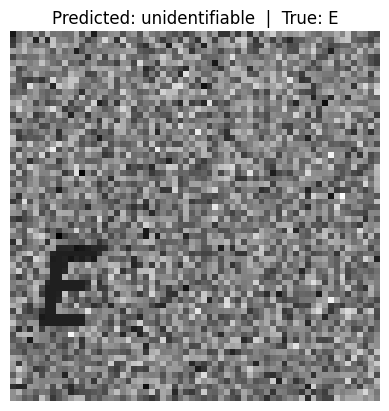

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# -----------------------------
# 1. Load the trained model
# -----------------------------
model = load_model("Symbol_Classifier_PAUL.h5")

# -----------------------------
# 2. Preprocess function for external images
# -----------------------------
def preprocess_image(path):
    img = tf.keras.preprocessing.image.load_img(
        path,
        color_mode="grayscale",
        target_size=(64, 64)
    )
    img = tf.keras.preprocessing.image.img_to_array(img)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)   # shape: (1, 64, 64, 1)
    return img

# -----------------------------
# 3. Predict on a validation sample
# -----------------------------
for images, labels in val_ds.take(1):
    sample_img = images[0].numpy()
    true_label = labels[0].numpy()
    break

pred = model.predict(sample_img.reshape(1, 64, 64, 1))
predicted_class = np.argmax(pred)

# -----------------------------
# 4. Display prediction
# -----------------------------
plt.imshow(sample_img.reshape(64, 64), cmap='gray')
plt.title(f"Predicted: {class_names[predicted_class]}  |  True: {class_names[true_label]}")
plt.axis('off')
plt.show()